# Making a new probe map for spike sorting with Spike Interface

### Plexon probes

In [1]:
from ripple_probe_maker import make_probe, combine_probes

probes_path = '/ihome/pmayo/knoneman/nhp-data-pipeline/probes'

In [ ]:
probe_name = 'sProbe_24chan_150umSpacing_750umToTip'

make_probe(
    probes_path,
    probe_name,
    num_columns=1,
    num_channels=24,
    ypitch=150,
    yshift=[750],
    contact_radius=7.5,
    show_fig=True
)

In [ ]:
probe_name = 'vProbe_24chan_150umSpacing_300umToTip'

make_probe(
    probes_path,
    probe_name,
    num_columns=1,
    num_channels=24,
    ypitch=150,
    yshift=[300],
    contact_radius=7.5,
    show_fig=True
)

In [ ]:
probe_name = 'vProbe_16chan_150umSpacing_300umToTip'

make_probe(
    probes_path,
    probe_name,
    num_columns=1,
    num_channels=16,
    ypitch=150,
    yshift=[750],
    contact_radius=7.5,
    show_fig=True
)

#### 1x 24-chan sProbe, 1x 24-chan vProbe

In [ ]:
num_columns = 1
num_channels = 24
ypitch = 150
yshift = 300

probe0 = generate_multi_columns_probe(num_columns=num_columns,
                                     num_contact_per_column=int(num_channels/num_columns), 
                                     ypitch=ypitch, 
                                     y_shift_per_column=[yshift],
                                     contact_shapes='circle',
                                     contact_shape_params={'radius':7.5}
                                    )

num_columns = 1
num_channels = 24
ypitch = 150
yshift = 750

probe1 = generate_multi_columns_probe(num_columns=num_columns,
                                     num_contact_per_column=int(num_channels/num_columns), 
                                     ypitch=ypitch, 
                                     y_shift_per_column=[yshift],
                                     contact_shapes='circle',
                                     contact_shape_params={'radius':7.5}
                                    )

probe1.move([500, 0])

probegroup = ProbeGroup()
probegroup.add_probe(probe0)
probegroup.add_probe(probe1)

channel_indices0 = np.array([16,14,12,10,8,6,4,2,31,29,27,25,23,21,19,17,15,13,11,9,7,5,3,1])
probe0.set_device_channel_indices(channel_indices0)

channel_indices1 = 127 + np.array([16,14,12,10,8,6,4,2,31,29,27,25,23,21,19,17,15,13,11,9,7,5,3,1])
probe1.set_device_channel_indices(channel_indices1)

print(probegroup.get_global_device_channel_indices())

fig, ax = plt.subplots(figsize=(25, 25))
plt.tight_layout()
plot_probegroup(probegroup, with_contact_id=True, with_device_index=True, same_axes=True, ax=ax)


[(0,  0) (0,  1) (0,  2) (0,  3) (0,  4) (0,  5) (0,  6) (0,  7) (0,  8)
 (0,  9) (0, 10) (0, 11) (0, 12) (0, 13) (0, 14) (0, 15) (0, 16) (0, 17)
 (0, 18) (0, 19) (0, 20) (0, 21) (0, 22) (0, 23)]


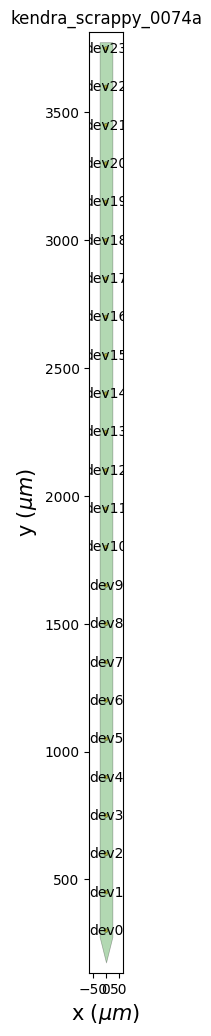

Saved probe JSON to /ix1/pmayo/lab_NHPdata/kendra_scrappy_0074a/kendra_scrappy_0074a_prbMap.json


In [2]:
session_path = "/ix1/pmayo/lab_NHPdata/kendra_scrappy_0074a"

combine_probes(session_path,probes_path,show_fig=True)


In [ ]:
plot_probegroup(combined_pg, same_axes=False, with_contact_id=True)
